## **Pivot Tables**

A pivot table in Pandas is used to **summarize and aggregate data** in a table format.

- `index` → rows
- `columns` → columns
- `values` → values to aggregate
- `aggfunc` → aggregation function (default is `mean`)

It is especially useful for **grouping data** and **computing statistics** across multiple categories.


In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv("students (1).csv")


In [3]:
# Basic pivot table: average age per education and department
df.pivot_table(index='education', columns='department', values='age')  

# Pivot table with sum aggregation
df.pivot_table(index='education', columns='department', values='age', aggfunc='sum')  

# Pivot table with multiple aggregation functions
df.pivot_table(index='education', columns='department', values='age', aggfunc=['mean','min','max'])  

# Pivot table including all columns
df.pivot_table(index='education', values=['age','id'], aggfunc='mean')  

# Pivot table with fill value for missing data
pt = df.pivot_table(index='education', columns='department', values='age', fill_value=0)  
value = pt.loc['PhD', 'economics']
print(value)

35.0


In [4]:
students_df = pd.read_csv("students (1).csv")
print(students_df.pivot_table(index='education', columns='department', values='age', aggfunc=['mean', 'min', 'max']))

                mean                                        min  \
department chemistry computer science economics  math chemistry   
education                                                         
BA              26.0             25.0      21.0  30.0      26.0   
MBA             31.0             27.0      20.0  27.0      31.0   
PhD             33.0              NaN      35.0  29.0      33.0   

                                                  max                   \
department computer science economics  math chemistry computer science   
education                                                                
BA                     25.0      21.0  30.0      26.0             25.0   
MBA                    27.0      20.0  27.0      31.0             27.0   
PhD                     NaN      34.0  29.0      33.0              NaN   

                            
department economics  math  
education                   
BA              21.0  30.0  
MBA             20.0  27.0  
PhD    

In [5]:
s1 = {1, 2, 3}
s2 = {3, 4, 5}
print(s1 | s2)



{1, 2, 3, 4, 5}


In [37]:
import pandas as pd
df1 = pd.DataFrame({'id': [1, 2, 3], 'val': ['a', 'b', 'c']})
df2 = pd.DataFrame({'id': [2, 3, 4], 'score': [90, 85, 70]})
result = pd.merge(df1, df2, on='id', how='inner')
print(len(result))
print(result)

2
   id val  score
0   2   b     90
1   3   c     85


In [39]:
import pandas as pd

# Creating two DataFrames with different columns
df1 = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
df2 = pd.DataFrame({'B': [5, 6], 'C': [7, 8]})

# 1. Outer Join (Union) - Default
# Result will have columns A, B, and C. Missing values filled with NaN.
outer_concat = pd.concat([df1, df2], join='outer', axis=0)

# 2. Inner Join (Intersection)
# Result will only have column B, as it is common to both.
outer_concat2 = pd.concat([df1, df2], join='outer', axis=1)

print("Outer Concat:\n", outer_concat)
print("\nOuter Concat:\n", outer_concat2)

Outer Concat:
      A  B    C
0  1.0  3  NaN
1  2.0  4  NaN
0  NaN  5  7.0
1  NaN  6  8.0

Outer Concat:
    A  B  B  C
0  1  3  5  7
1  2  4  6  8


In [8]:
import pandas as pd

# 1. Create a sample DataFrame
data = {
    'Region': ['North', 'North', 'South', 'South', 'North', 'South'],
    'Product': ['Apples', 'Bananas', 'Apples', 'Bananas', 'Bananas', 'Apples'],
    'Sales': [100, 150, 200, 50, 120, 300],
    'Inventory': [10, 20, 15, 5, 25, 30]
}
df = pd.DataFrame(data)

# 2. Group by Region and Product, then sum the numerical columns
# This will sum both 'Sales' and 'Inventory'
result = df.groupby(['Region', 'Product']).sum()

print("Grouped DataFrame:")
print(result)

# 3. Accessing data in a MultiIndex result
# To get the sum for specifically North Region Bananas:
north_bananas_sales = result.loc[('North', 'Bananas'), 'Sales']
print(f"\nTotal Sales for North Bananas: {north_bananas_sales}")

Grouped DataFrame:
                Sales  Inventory
Region Product                  
North  Apples     100         10
       Bananas    270         45
South  Apples     500         45
       Bananas     50          5

Total Sales for North Bananas: 270


In [9]:
df = pd.DataFrame({'A': [1, np.nan, 3],
                   'B': [4, 5, 6]})
df['A'] = df['A'].fillna(df['A'].mean())
print(df['A'].tolist())



[1.0, 2.0, 3.0]


In [10]:
import pandas as pd
data = {'name': ['Alice', 'Bob', 'Charlie'],
        'score': [85, 90, 78]}
df = pd.DataFrame(data)
print(df[df['score'] > 80]['name'].tolist())

result = [x**2 for x in range(1, 6)]
print(result[2])

s = {1, 2, 3}
s.add(2)
s.add(4)
print(len(s))

import numpy as np
arr = np.array([10, 20, 30, 40, 50])
print(arr[1:4].sum())


d1 = {'a': 1, 'b': 2}
d2 = {'b': 3, 'c': 4}
d1.update(d2)
print(d1)




['Alice', 'Bob']
9
4
90
{'a': 1, 'b': 3, 'c': 4}


In [11]:
df1 = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
df2 = pd.DataFrame({'C': [5, 6], 'D': [7, 8]})
result1 = pd.concat([df1, df2], join='outer', axis=1)
result2 = pd.concat([df1, df2], join='outer', axis=0)


print(result1.shape)
print(result1)
print(result2.shape)
print(result2)


(2, 4)
   A  B  C  D
0  1  3  5  7
1  2  4  6  8
(4, 4)
     A    B    C    D
0  1.0  3.0  NaN  NaN
1  2.0  4.0  NaN  NaN
0  NaN  NaN  5.0  7.0
1  NaN  NaN  6.0  8.0


In [12]:
import requests
response = requests.get('https://www.usatoday.com/')
content  = response.content
print(response.status_code)
print(len(content))


200
238905


In [13]:
from bs4 import BeautifulSoup
soup = BeautifulSoup(content, 'html.parser')
print(soup.title.string)

USA TODAY - Breaking News and Latest News Today


In [14]:
# Get the href of the first <a class="gnt_m_th_a">
print(soup.find_all('a', class_='gnt_m_th_a')[0].get('href'))

# For all <a class="gnt_m_th_a">, print their href attribute
for t in soup.find_all('a', class_='gnt_m_th_a'):
    print(t.get('href'))

news = [t.get('href') for t in soup.find_all('a', class_='gnt_m_th_a')]
f = open("news_links.txt", "a")
for link in news:
    f.write("\n".join(link))
f.close()

/story/news/world/2026/03/03/why-is-us-at-war-with-iran/88950408007/
/story/news/world/2026/03/03/why-is-us-at-war-with-iran/88950408007/
/story/news/politics/2026/03/04/james-talarico-beats-jasmine-crockett-texas-senate-primary/88980335007/
/story/news/politics/2026/03/04/trump-iran-venezuela-foreign-relations/88959676007/
/story/graphics/2026/03/03/gas-prices-iran-strait-of-hormuz-map/88959202007/
/story/entertainment/books/2026/03/04/acotar-sarah-j-maas-call-her-daddy/88967709007/
/story/travel/2026/03/03/united-airlines-headphones-passengers-flights-policy/88971122007/
/story/entertainment/music/2026/03/04/woodz-interview-album-archive1-kpop/88876584007/
/story/news/nation/2026/03/04/feds-speed-up-butchering-speeds-food-costs/88959889007/


In [15]:
! which python

/Users/owenhuang/.pyenv/versions/pythonfordata312/bin/python


In [16]:
import pandas as pd

# 1. Create a sample DataFrame
data = {
    'Department': ['IT', 'HR', 'IT', 'HR', 'Sales', 'Sales', 'IT'],
    'Salary': [60000, 50000, 75000, 55000, 80000, 90000, 65000]
}
df = pd.DataFrame(data)

print("--- Original DataFrame ---")
print(df)
print("\n")

# 2. Run the command from the quiz
result = df.groupby('Department').agg({'Salary': ['mean', 'max']})

print("--- Resulting DataFrame ---")
print(result)
import pandas as pd

data = {
    'Department': ['IT', 'HR', 'IT', 'HR', 'Sales', 'Sales', 'IT'],
    'Salary': [60000, 50000, 75000, 55000, 80000, 90000, 65000]
}
df = pd.DataFrame(data)

# 1. Group by Department, get mean and max salary (your original)
print(df.groupby('Department').agg({'Salary': ['mean', 'max']}))

# 2. Group by Department, get min and sum salary
print(df.groupby('Department').agg({'Salary': ['min', 'sum']}))

# 3. Group by Department, get count of employees
print(df.groupby('Department').agg({'Salary': 'count'}))

# 4. Group by Department, get all stats at once
print(df.groupby('Department')['Salary'].describe())

# 5. Group by Department, get mean salary and also show as a Series
print(df.groupby('Department')['Salary'].mean())

# 6. Group by Department, get multiple aggregations with .agg and named columns
print(df.groupby('Department').agg(
    mean_salary=('Salary', 'mean'),
    max_salary=('Salary', 'max'),
    min_salary=('Salary', 'min'),
    employee_count=('Salary', 'count')
))

--- Original DataFrame ---
  Department  Salary
0         IT   60000
1         HR   50000
2         IT   75000
3         HR   55000
4      Sales   80000
5      Sales   90000
6         IT   65000


--- Resulting DataFrame ---
                  Salary       
                    mean    max
Department                     
HR          52500.000000  55000
IT          66666.666667  75000
Sales       85000.000000  90000
                  Salary       
                    mean    max
Department                     
HR          52500.000000  55000
IT          66666.666667  75000
Sales       85000.000000  90000
           Salary        
              min     sum
Department               
HR          50000  105000
IT          60000  200000
Sales       80000  170000
            Salary
Department        
HR               2
IT               3
Sales            2
            count          mean          std      min      25%      50%  \
Department                                                       

In [17]:
np.zeros((2, 3, 4))

array([[[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]]])

In [18]:
arr = np.array([10, 20, 30, 40, 50])
print(arr[[0, 2, 2
, 4]])  # Output: [10 30 30 50] 




[10 30 30 50]


In [19]:
nums = [1, 2, 3, 4, 5]

# The lambda function checks if a number is even (x % 2 == 0)
# filter() keeps only the items where the condition is True
result = list(filter(lambda x: x % 2 == 0, nums))

print(result) 
# Output: [2, 4]

[2, 4]


In [20]:
word = "data"
print(set(word))
print({char: word.count(char) for char in set(word)})




{'a', 't', 'd'}
{'a': 2, 't': 1, 'd': 1}


## **Combining DataFrames**

In [21]:
import numpy as np
import pandas as pd

## `pd.concat()`

`pd.concat()` is a **Pandas function used to combine multiple DataFrames or Series** along a specified axis.

- **`axis=0`** → Stacks data **vertically** (adds rows).
- **`axis=1`** → Combines data **horizontally** (adds columns).
- **`join='outer'`** → Keeps all indexes (union of indexes).
- **`join='inner'`** → Keeps only common indexes (intersection of indexes).

It is commonly used to append datasets or combine related data structures into a single DataFrame.

In [22]:
df1=pd.DataFrame(np.arange(9).reshape(3,3), columns=['a','b','c'], index=['one', 'two', 'three'])
df1

,a,b,c
one,0,1,2
two,3,4,5
three,6,7,8


In [23]:
s1 = pd.Series([1, 2], index=['A', 'B'])
s2 = pd.Series([3, 4], index=['B', 'C'])
result = s1 + s2
print(result)
print(s1)
print(s2)

A    NaN
B    5.0
C    NaN
dtype: float64
A    1
B    2
dtype: int64
B    3
C    4
dtype: int64


In [24]:
arr = np.array([2, 4, 6, 8])
print(arr > 5)

[False False  True  True]


In [25]:
matrix = [[1, 2], [3, 4]]
print([num for row in matrix for num in row])




[1, 2, 3, 4]


In [26]:
print([x for x in range(10) if x % 2 == 0 if x > 4])


[6, 8]


In [27]:
df2=pd.DataFrame(np.arange(6).reshape(3,2), columns=['d','e'], index=['three', 'two', 'One'])
df2

,d,e
three,0,1
two,2,3
One,4,5


In [28]:
pd.concat([df1, df2], axis=0)                # Stack rows vertically (default behavior), matching columns by name
pd.concat([df1, df2], axis=1)                # Combine columns side-by-side, aligning rows by index (outer join by default)
pd.concat([df1, df2], axis=1, join='outer')  # Side-by-side with all indexes included (union of indexes, may create NaNs)
pd.concat([df1, df2], axis=1, join='inner')  # Side-by-side with only common indexes kept (intersection of indexes)

,a,b,c,d,e
two,3,4,5,2,3
three,6,7,8,0,1


In [29]:
pd.concat([df1, df2], axis=0)                # Stack rows vertically (default behavior), matching columns by name


,a,b,c,d,e
one,0.0,1.0,2.0,NaN,NaN
two,3.0,4.0,5.0,NaN,NaN
three,6.0,7.0,8.0,NaN,NaN
three,NaN,NaN,NaN,0.0,1.0
two,NaN,NaN,NaN,2.0,3.0
One,NaN,NaN,NaN,4.0,5.0


In [30]:
pd.concat([df1, df2], axis=1)                # Combine columns side-by-side, aligning rows by index (outer join by default)


,a,b,c,d,e
one,0.0,1.0,2.0,NaN,NaN
two,3.0,4.0,5.0,2.0,3.0
three,6.0,7.0,8.0,0.0,1.0
One,NaN,NaN,NaN,4.0,5.0


## `pd.merge()`

`pd.merge()` is a **Pandas function used to combine DataFrames based on common column(s) or key(s)** (similar to SQL joins).

- **`on='col'`** → Column name used as the join key (must exist in both DataFrames).
- **`left_on` / `right_on`** → Use different column names as join keys.
- **`how='inner'`** → Keeps only matching rows (default).
- **`how='left'`** → Keeps all rows from the left DataFrame.
- **`how='right'`** → Keeps all rows from the right DataFrame.
- **`how='outer'`** → Keeps all rows from both DataFrames.

It is commonly used when combining datasets that share a common identifier (e.g., ID, email, product code).

In [31]:
df3=pd.DataFrame([['a','b','c'], ['d','e','f'],['g','h','i']], columns=['col1', 'col2', 'col3'])
df3

,col1,col2,col3
0,a,b,c
1,d,e,f
2,g,h,i


In [32]:
df4=pd.DataFrame([['x',1,'i'], ['e',2,'f'], ['b',3,'e'],['z',4,'h']], columns=['col2', 'col4', 'col5'])
df4

,col2,col4,col5
0,x,1,i
1,e,2,f
2,b,3,e
3,z,4,h


In [33]:
pd.merge(df3, df4, how='outer')            # Keep all rows from both DataFrames (union of keys, fills unmatched with NaN)
pd.merge(df3, df4, how='inner')            # Keep only rows with matching keys in both DataFrames (intersection)
pd.merge(df3, df4, on='col2', how='left')  # Keep all rows from df3, match on 'col2', fill unmatched df4 values with NaN
pd.merge(df3, df4, on='col2', how='right') # Keep all rows from df4, match on 'col2', fill unmatched df3 values with NaN
pd.merge(df3, df4, left_on='col2', right_on='col5', how='inner')  # Match df3['col2'] with df4['col5'], keep only matching rows

,col1,col2_x,col3,col2_y,col4,col5
0,d,e,f,b,3,e
1,g,h,i,z,4,h


In [34]:
pd.merge(df3, df4, how='outer')            # Keep all rows from both DataFrames (union of keys, fills unmatched with NaN)


,col1,col2,col3,col4,col5
0,a,b,c,3.0,e
1,d,e,f,2.0,f
2,g,h,i,NaN,NaN
3,NaN,x,NaN,1.0,i
4,NaN,z,NaN,4.0,h


In [35]:
import pandas as pd

# HR table
HR = pd.DataFrame(
    {
        "index": [1, 2, 3, 4],
        "Name": ["Mike", "Sarah", "Tara", "William"],
        "age": [25, 20, 22, 19],
    }
)

# Payroll table
payroll = pd.DataFrame(
    {
        "index": [1, 2, 3, 4],
        "FName": ["Mike", "Tara", "Sarah", "Alma"],
        "Salary": [2000, 3000, 2500, 5000],
    }
)

# Merge (outer join) on HR.Name == payroll.FName
result = pd.merge(HR, payroll, left_on="Name", right_on="FName", how="outer")

print("HR:\n", HR, "\n")
print("Payroll:\n", payroll, "\n")
print("Merged (outer):\n", result)

HR:
    index     Name  age
0      1     Mike   25
1      2    Sarah   20
2      3     Tara   22
3      4  William   19 

Payroll:
    index  FName  Salary
0      1   Mike    2000
1      2   Tara    3000
2      3  Sarah    2500
3      4   Alma    5000 

Merged (outer):
    index_x     Name   age  index_y  FName  Salary
0      NaN      NaN   NaN      4.0   Alma  5000.0
1      1.0     Mike  25.0      1.0   Mike  2000.0
2      2.0    Sarah  20.0      3.0  Sarah  2500.0
3      3.0     Tara  22.0      2.0   Tara  3000.0
4      4.0  William  19.0      NaN    NaN     NaN


In [36]:
# df1 has ids 1, 2, 3
# df3 has ids 8, 9, 10
df3 = pd.DataFrame({
    'id': [8, 9, 10],
    'value': ['P', 'Q', 'R']
})

empty_result = pd.merge(df1, df3, on='id', how='inner')

print("Columns:", empty_result.columns.tolist())
print("Resulting Rows:\n", empty_result)

KeyError: 'id'

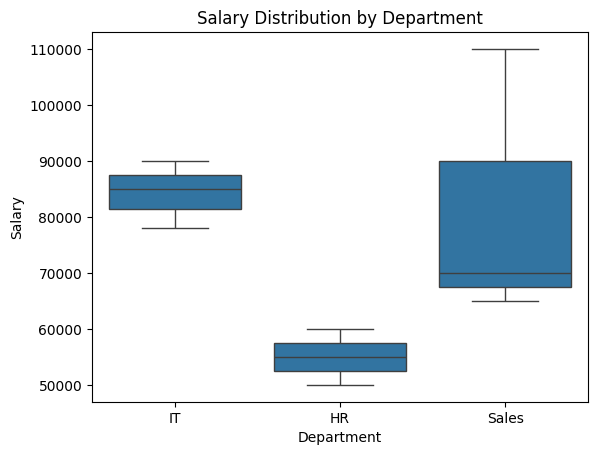

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create sample data
data = {
    'Department': ['IT', 'IT', 'IT', 'HR', 'HR', 'HR', 'Sales', 'Sales', 'Sales'],
    'Salary': [85000, 90000, 78000, 50000, 60000, 55000, 70000, 110000, 65000]
}
df = pd.DataFrame(data)

# 2. Create the boxplot
# x is the categorical group, y is the numerical value
sns.boxplot(x='Department', y='Salary', data=df)

# 3. Add titles for clarity
plt.title('Salary Distribution by Department')
plt.show()

In [ ]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# Option A: Using np.dot()
result = np.dot(a, b)

# Option B: Using the @ operator (Python 3.5+)
result = a @ b

print(result)  # Output: 32 (1*4 + 2*5 + 3*6)

32


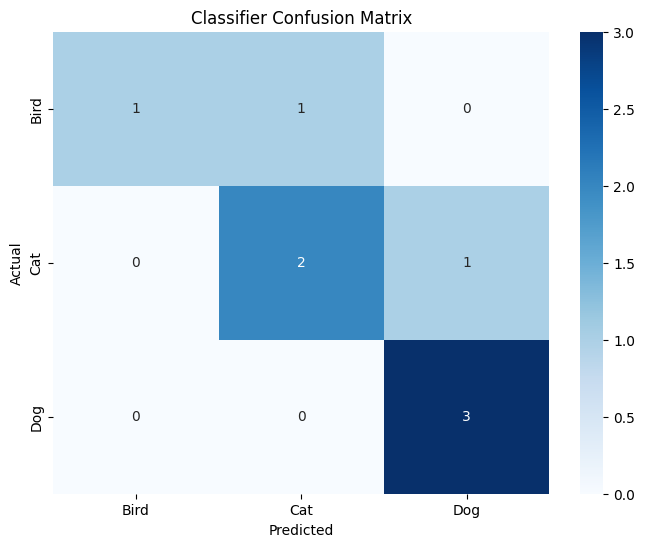

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Example Data: True labels vs Predicted labels
y_true = ['Cat', 'Dog', 'Cat', 'Cat', 'Dog', 'Bird', 'Bird', 'Dog']
y_pred = ['Cat', 'Dog', 'Dog', 'Cat', 'Dog', 'Bird', 'Cat', 'Dog']
labels = ['Bird', 'Cat', 'Dog']

# 2. Create the confusion matrix numerical array
cm = confusion_matrix(y_true, y_pred, labels=labels)

# 3. Create the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True,    # Show the numbers in the cells
            fmt='d',       # Format as integers
            cmap='Blues',  # Color gradient (light to dark blue)
            xticklabels=labels, 
            yticklabels=labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Classifier Confusion Matrix')
plt.show()

In [ ]:
list(zip(*[('a', 1), ('b', 2), ('c', 3)]))

[('a', 'b', 'c'), (1, 2, 3)]

In [ ]:
list(zip([1, 2], [3, 4], [5, 6]))

[(1, 3, 5), (2, 4, 6)]

In [ ]:
nums = [10, 20, 30]
it = iter(nums)
print(next(it))

10


In [ ]:
print(next(it))

20


In [ ]:
import pandas as pd

# 1. Create a sample DataFrame
data = {
    'Department': ['IT', 'HR', 'IT', 'HR', 'Sales', 'Sales'],
    'Salary': [90000, 60000, 95000, 65000, 70000, 75000],
    'Bonus': [5000, 3000, 6000, 3500, 8000, 9000]
}
df = pd.DataFrame(data)

# 2. Calculate the average Salary and sum of Bonus per Department
result = df.groupby('Department').agg({
    'Salary': ['mean', 'max'],
    'Bonus': 'sum'
})
print(result)

result = df.groupby('Department').agg({"Salary": ["mean", "max"], "Bonus": "sum"})
print(result)

             Salary         Bonus
               mean    max    sum
Department                       
HR          62500.0  65000   6500
IT          92500.0  95000  11000
Sales       72500.0  75000  17000
             Salary         Bonus
               mean    max    sum
Department                       
HR          62500.0  65000   6500
IT          92500.0  95000  11000
Sales       72500.0  75000  17000


In [ ]:
from functools import reduce
reduce(lambda x, y: x * y, [1, 2, 3, 4])

24

In [ ]:
import pandas as pd

# df1 has columns 'A' and 'B'
df1 = pd.DataFrame({
    'A': [1, 2],
    'B': [3, 4]
})

# df2 has columns 'B' and 'C' (it's missing 'A', and df1 is missing 'C')
df2 = pd.DataFrame({
    'B': [5, 6],
    'C': [7, 8]
})

# Stack them vertically
result = pd.concat([df1, df2], axis=0)

print(result)

     A  B    C
0  1.0  3  NaN
1  2.0  4  NaN
0  NaN  5  7.0
1  NaN  6  8.0


In [ ]:
data = np.array([10, 20, 30, 40])
len(data[data >= 30])

2

In [ ]:
import pandas as pd

# Create two DataFrames
df1 = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
df2 = pd.DataFrame({'A': [5, 6], 'B': [7, 8]})

# concat: stacks them vertically (axis=0)
concat_result = pd.concat([df1, df2], axis=0)
print("Concat result:\n", concat_result)

# merge: joins on column 'A'
df3 = pd.DataFrame({'A': [1, 2, 5], 'C': ['x', 'y', 'z']})
merge_result = pd.merge(df1, df3, on='A', how='inner')
print("Merge result:\n", merge_result)

Concat result:
    A  B
0  1  3
1  2  4
0  5  7
1  6  8
Merge result:
    A  B  C
0  1  3  x
1  2  4  y


In [ ]:
import json

# 1. Create a sample Python dictionary
data = {
    "name": "Alice",
    "age": 28,
    "role": "Data Scientist",
    "skills": ["Python", "Pandas", "SQL"]
}

# 2. Write the dictionary to a JSON file
# 'w' opens the file in write mode. The 'with' statement ensures the file 
# closes automatically when the block is finished.
with open('output.json', 'w') as f:
    json.dump(data, f, indent=4)  # indent=4 makes the output file easy to read

print("Successfully saved 'data' to output.json!")

Successfully saved 'data' to output.json!


In [ ]:
import pandas as pd

# 1. Create a sample DataFrame
data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35],
    'City': ['New York', 'Los Angeles', 'Chicago']
}
df = pd.DataFrame(data)

print("Original DataFrame:")
print(df)
print("-" * 30)

# 2. Save to CSV WITHOUT the numeric row index (The correct quiz answer)
df.to_csv('output.csv', index=False)
print(df)
df2 = pd.read_csv('output.csv')
print("DataFrame read back from output.csv:")
print(df2)
print("Successfully saved 'df' to output.csv without the index!")

Original DataFrame:
      Name  Age         City
0    Alice   25     New York
1      Bob   30  Los Angeles
2  Charlie   35      Chicago
------------------------------
      Name  Age         City
0    Alice   25     New York
1      Bob   30  Los Angeles
2  Charlie   35      Chicago
DataFrame read back from output.csv:
      Name  Age         City
0    Alice   25     New York
1      Bob   30  Los Angeles
2  Charlie   35      Chicago
Successfully saved 'df' to output.csv without the index!
